# Shock Cord Load and Factor of Safety

This notebook estimates the force during **main parachute deployment** and compares it against the rated strength of **1/4 in Amsteel Blue** to compute factor of safety.

Force model used:
- Average deployment tension: $F = m\left(\frac{|\Delta v|}{\Delta t} + g\right)$
- Additional max deployment tension calculated using $F = m * a_{\max}$
- Factor of safety: $FoS = \frac{Strength}{Load}$


In [73]:
# Inputs (edit these for your flight)
mass_lbm = 35  # Rocket mass at main deployment, lbm
v_before_main_fts = 172.2  # Descent speed before main deployment, ft/s
v_after_main_fts = 14.9  # Descent speed after inflation/stabilization, ft/s
deployment_time_s = 0.40  # Time over which velocity change occurs, seconds
max_g = 50.0  # Maximum expected deceleration in g's for a peak-load case
required_fos = 3.0
knot_efficiency = 0.50  # Conservative retained strength fraction for a knotted termination

# 1/4 in Amsteel Blue minimum break strength (typical published value)
amsteel_strength_lbf = 8600.0

# Constants
KG_PER_LBM = 0.45359237
M_PER_FT = 0.3048
N_PER_LBF = 4.4482216152605
g = 9.80665

# Derived inputs (convert to SI units for calculations)
mass_kg = mass_lbm * KG_PER_LBM
v_before_main_mps = v_before_main_fts * M_PER_FT
v_after_main_mps = v_after_main_fts * M_PER_FT

# Strength cases reused in the calculations, design check, and plot
strength_lbf = {
    "Amsteel Blue (static)": amsteel_strength_lbf,
    "Amsteel Blue (dynamic)": amsteel_strength_lbf / 3.0,
    "Amsteel Blue (dynamic + knot)": (amsteel_strength_lbf / 3.0) * knot_efficiency,
}

In [74]:
# Calculations
delta_v = abs(v_before_main_mps - v_after_main_mps)
a_mag = delta_v / deployment_time_s
a_mag_g = a_mag / g

avg_tension_N = mass_kg * (a_mag + g)
peak_tension_N = mass_kg * max_g * g

loads_N = {
    "Average deployment load": avg_tension_N,
    f"Peak load at {max_g:.0f} g": peak_tension_N,
}
loads_lbf = {name: value / N_PER_LBF for name, value in loads_N.items()}

amsteel_strength_N = amsteel_strength_lbf * N_PER_LBF
fos = {
    strength_name: {
        load_name: strength_value / load_value
        for load_name, load_value in loads_lbf.items()
    }
    for strength_name, strength_value in strength_lbf.items()
}

print(f"Estimated deceleration magnitude: {a_mag:.2f} m/s^2 ({a_mag_g:.2f} g)")
print(f"Delta-V across main deployment: {delta_v:.2f} m/s ({delta_v / M_PER_FT:.1f} ft/s)")
print()
print("Load cases:")
for name, load_value in loads_lbf.items():
    print(f"- {name}: {load_value:,.1f} lbf ({load_value * N_PER_LBF:,.0f} N)")
print()
print("Strength cases:")
for name, strength_value in strength_lbf.items():
    print(f"- {name}: {strength_value:,.0f} lbf ({strength_value * N_PER_LBF:,.0f} N)")

Estimated deceleration magnitude: 119.86 m/s^2 (12.22 g)
Delta-V across main deployment: 47.95 m/s (157.3 ft/s)

Load cases:
- Average deployment load: 462.8 lbf (2,059 N)
- Peak load at 50 g: 1,750.0 lbf (7,784 N)

Strength cases:
- Amsteel Blue (static): 8,600 lbf (38,255 N)
- Amsteel Blue (dynamic): 2,867 lbf (12,752 N)
- Amsteel Blue (dynamic + knot): 1,433 lbf (6,376 N)


In [75]:
# Factor-of-safety summary and design check
import pandas as pd

design_strength_case = "Amsteel Blue (dynamic + knot)"
design_load_case = f"Peak load at {max_g:.0f} g"

rows = []
for strength_name, row in fos.items():
    for load_name, value in row.items():
        rows.append(
            {
                "Strength case": strength_name,
                "Load case": load_name,
                "FoS": round(value, 2),
                "Target FoS": required_fos,
                "Meets target": "PASS" if value >= required_fos else "CHECK",
            }
        )

fos_table = pd.DataFrame(rows)
fos_table["Design case"] = (
    (fos_table["Strength case"] == design_strength_case)
    & (fos_table["Load case"] == design_load_case)
).map({True: "<- selected", False: ""})

design_row = fos_table.loc[
    (fos_table["Strength case"] == design_strength_case)
    & (fos_table["Load case"] == design_load_case)
].iloc[0]
design_fos = float(design_row["FoS"])

display(fos_table)

print()
if design_fos >= required_fos:
    print(
        f"PASS: {design_strength_case} vs {design_load_case} gives FoS = "
        f"{design_fos:.2f}, meeting target >= {required_fos:.1f}"
    )
else:
    print(
        f"CHECK DESIGN: {design_strength_case} vs {design_load_case} gives FoS = "
        f"{design_fos:.2f}, below target >= {required_fos:.1f}"
    )

,Strength case,Load case,FoS,Target FoS,Meets target,Design case
0,Amsteel Blue (static),Average deployment load,18.58,3.0,PASS,
1,Amsteel Blue (static),Peak load at 50 g,4.91,3.0,PASS,
2,Amsteel Blue (dynamic),Average deployment load,6.19,3.0,PASS,
3,Amsteel Blue (dynamic),Peak load at 50 g,1.64,3.0,CHECK,
4,Amsteel Blue (dynamic + knot),Average deployment load,3.10,3.0,PASS,
5,Amsteel Blue (dynamic + knot),Peak load at 50 g,0.82,3.0,CHECK,<- selected



CHECK DESIGN: Amsteel Blue (dynamic + knot) vs Peak load at 50 g gives FoS = 0.82, below target >= 3.0


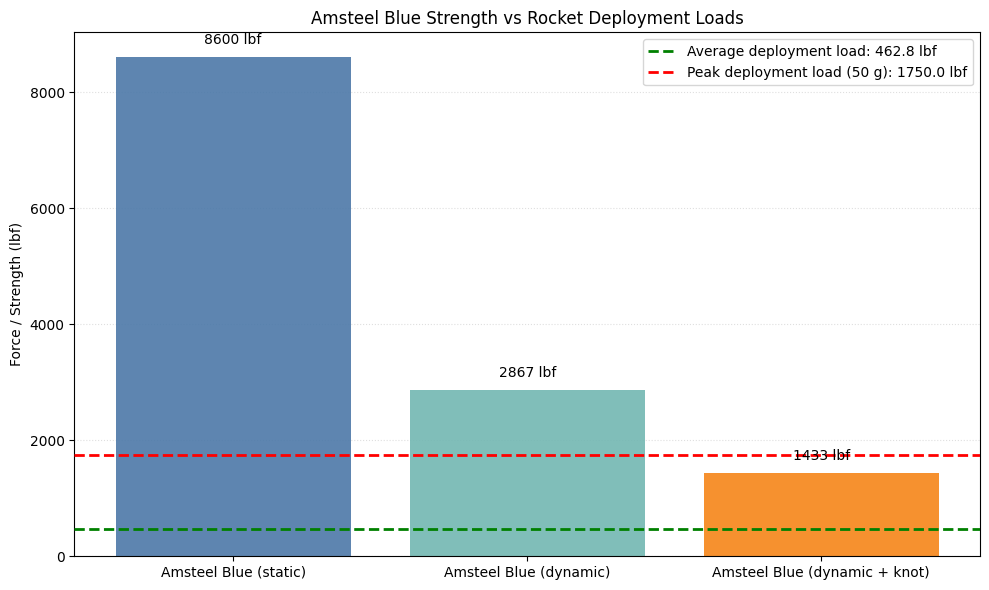

In [76]:
import matplotlib.pyplot as plt

labels = list(strength_lbf.keys())
strength_values = [strength_lbf[label] for label in labels]
avg_load_lbf = loads_lbf["Average deployment load"]
peak_load_lbf = loads_lbf[f"Peak load at {max_g:.0f} g"]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    labels,
    strength_values,
    color=["#4c78a8", "#72b7b2", "#f58518"],
    alpha=0.9,
    zorder=2,
 )

ax.axhline(
    avg_load_lbf,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Average deployment load: {avg_load_lbf:.1f} lbf",
    zorder=3,
 )
ax.axhline(
    peak_load_lbf,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Peak deployment load ({max_g:.0f} g): {peak_load_lbf:.1f} lbf",
    zorder=3,
 )

label_offset = max(strength_values) * 0.02
for bar, value in zip(bars, strength_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + label_offset,
        f"{value:.0f} lbf",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_ylabel("Force / Strength (lbf)")
ax.set_title("Amsteel Blue Strength vs Rocket Deployment Loads")
ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=1)
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Notes
- Update inputs with your measured pre-main and post-main descent rates from flight data.
- Deployment time is often the largest uncertainty; run sensitivity checks across plausible values.
- Published line strength can vary by manufacturer and knot/splice method. Use your exact hardware specification when finalizing FoS.
